In [1]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga del DataSet
df = pd.read_csv("netflix_titles.csv")

In [3]:
# Mostrar las primeras filas
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [4]:
# Mostrar las dimensiones
df.shape

(8807, 12)

In [5]:
# Mostrar los nombres de columnas
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
# Mostrar tipos de datos
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [7]:
# Identificar valores nulos
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
# Calcular porcentaje de valores faltantes
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [9]:
# Detectar registros duplicados
df.duplicated().sum()

np.int64(0)

In [10]:
# --- ESTRATEGIA DE LIMPIEZA SIMPLIFICADA (Estilo Lab04) ---

# 1. Eliminamos la columna 'director' por tener casi 30% de nulos (igual que se eliminó 'cabin' en Lab04)
df.drop(columns=["director"], inplace=True)

# 2. Rellenamos los nulos de las demás columnas usando la moda (el valor más repetido)
df["country"] = df["country"].fillna(df["country"].mode()[0])
df["cast"] = df["cast"].fillna(df["cast"].mode()[0])
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

# Confirmamos que ya no hay valores nulos
df.isnull().sum()

show_id         0
type            0
title           0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

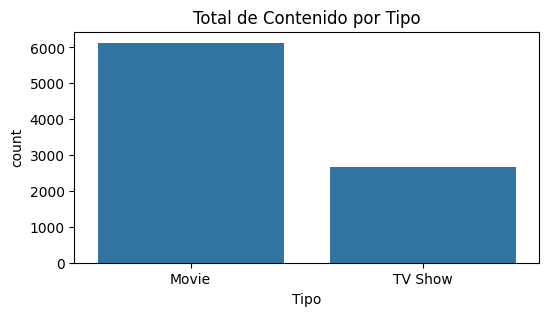

In [11]:
# Gráfica 1: Total de títulos por tipo (Película vs Serie)
plt.figure(figsize=(6,3))
sns.countplot(df, x="type")
plt.title("Total de Contenido por Tipo")
plt.xlabel("Tipo")
plt.show()

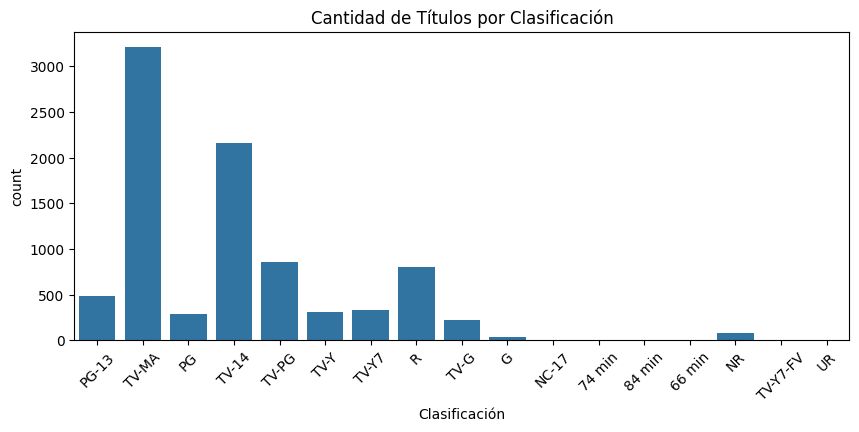

In [12]:
# Gráfica 2: Distribución de las clasificaciones (Rating)
plt.figure(figsize=(10,4))
sns.countplot(df, x="rating")
plt.title("Cantidad de Títulos por Clasificación")
plt.xlabel("Clasificación")
plt.xticks(rotation=45)
plt.show()

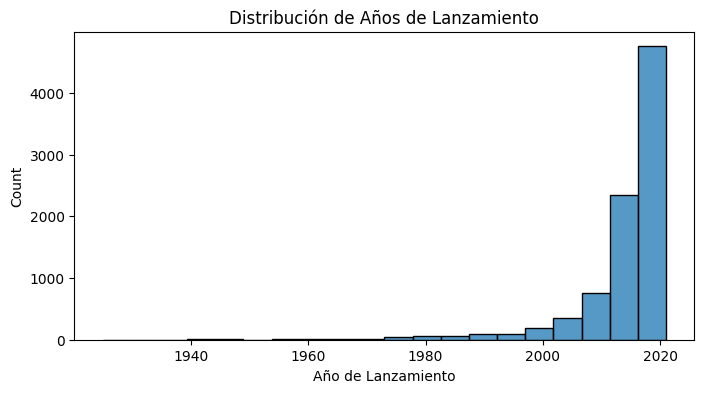

In [13]:
# Gráfica 3: Histograma de los años de lanzamiento
plt.figure(figsize=(8,4))
sns.histplot(df, x="release_year", bins=20)
plt.title("Distribución de Años de Lanzamiento")
plt.xlabel("Año de Lanzamiento")
plt.show()

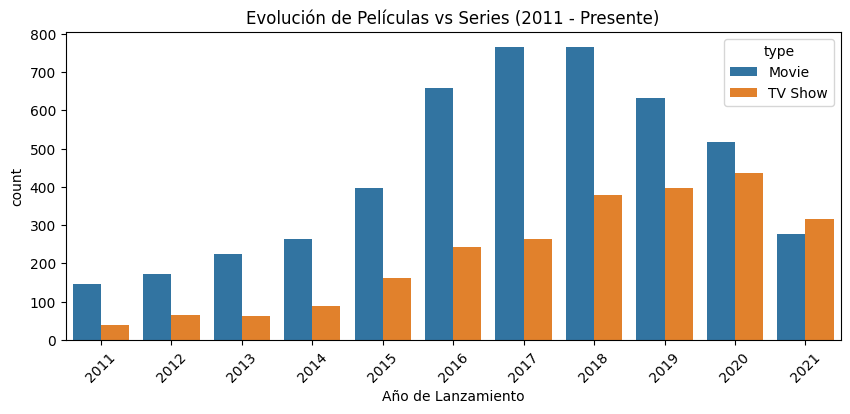

In [14]:
# Gráfica 4: Relación del tipo de contenido en los últimos años (de 2010 en adelante)
plt.figure(figsize=(10,4))
sns.countplot(df[df["release_year"] > 2010], x="release_year", hue="type")
plt.title("Evolución de Películas vs Series (2011 - Presente)")
plt.xlabel("Año de Lanzamiento")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Conclusión 1: Netflix tiene más Películas que Series en su catálogo
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [16]:
# Conclusión 2: La clasificación más común es para público adulto (TV-MA)
df["rating"].value_counts().head(3)

rating
TV-MA    3211
TV-14    2160
TV-PG     863
Name: count, dtype: int64

In [17]:
# Conclusión 3: La mayor cantidad de películas y series se lanzaron de 2015 en adelante
df[df["release_year"] >= 2015]["release_year"].count()

np.int64(6216)